# 🧠 MultiModal RAG — Quickstart (Free Stack)

**Zero cost. No OpenAI. No Docker.**

| Component | Tool | Cost |
|-----------|------|------|
| PDF Parsing | Ollama + `glm-ocr` | Free |
| Image Captioning | Groq `qwen/qwen3.6-27b` | Free tier |
| Embeddings | `sentence-transformers` CPU | Free |
| Re-ranking | BGE local | Free |
| Vector DB | Qdrant binary | Free |

### Run cells in order: 0 → 1 → 2 → 5 → 6 → 7 → 8 → 9

## 🔧 Cell 0 — Preflight: Check Ollama

Run this first. `glm-ocr` needs Ollama ≥ 0.5 (system has 0.1.27).

In [1]:
import subprocess

v = subprocess.run(['ollama','--version'], capture_output=True, text=True)
print('Ollama:', v.stdout.strip())

models = subprocess.run(['ollama','list'], capture_output=True, text=True)
if 'glm-ocr' in models.stdout:
    print('✅ glm-ocr ready')
else:
    print('✗ glm-ocr not found — need to update Ollama:')
    print()
    print('In a terminal (with sudo):')
    print('  curl -fsSL https://ollama.com/install.sh | sudo sh')
    print('  ollama pull glm-ocr:latest')
    print()
    print('Without sudo (snap):')
    print('  sudo snap install ollama')

Ollama: ollama version is 0.32.5
✅ glm-ocr ready


## ⚙️ Cell 1 — Load Settings

In [2]:
import sys, os
sys.path.insert(0, '../src')
from dotenv import load_dotenv
load_dotenv('../.env', override=True)

from doc_parser.config import get_settings, configure_logging
configure_logging('INFO')
settings = get_settings()

print('✅ Settings loaded')
print(f'  parser_backend     : {settings.parser_backend}')
print(f'  embedding_provider : {settings.embedding_provider} ({settings.embedding_model}, {settings.embedding_dimensions}d)')
print(f'  reranker_backend   : {settings.reranker_backend}')
print(f'  groq_api_key       : {"set ✓" if settings.groq_api_key else "NOT SET ✗"}')
print(f'  qdrant_url         : {settings.qdrant_url}')
print(f'  image_caption      : {settings.image_caption_enabled}')

✅ Settings loaded
  parser_backend     : ollama
  embedding_provider : local (all-MiniLM-L6-v2, 384d)
  reranker_backend   : bge
  groq_api_key       : set ✓
  qdrant_url         : https://491a2582-7d00-4644-9809-a3faab7fab8a.eu-west-2-0.aws.cloud.qdrant.io
  image_caption      : True


## 🗄️ Cell 2 — Qdrant Health Check

**Option A — Local binary** (running via `nohup /home/user/qdrant/qdrant &`)
**Option B — Qdrant Cloud** (if you ingested via Colab): set `QDRANT_URL` and `QDRANT_API_KEY` in `.env`

The notebook reads from whichever `QDRANT_URL` is set in your `.env`.

In [3]:
import httpx, asyncio

async def check_qdrant():
    try:
        async with httpx.AsyncClient(timeout=3) as c:
            r = await c.get(f'{settings.qdrant_url}/healthz')
        print(f'✅ Qdrant UP at {settings.qdrant_url} (HTTP {r.status_code})')
    except Exception as e:
        print(f'✗ Qdrant not reachable: {e}')
        print()
        print('Start it — Option A (binary, no Docker):')
        print('  mkdir -p ~/qdrant && cd ~/qdrant')
        print('  wget https://github.com/qdrant/qdrant/releases/latest/download/qdrant-x86_64-unknown-linux-musl.tar.gz')
        print('  tar -xzf qdrant*.tar.gz && ./qdrant &')
        print()
        print('Option B — Qdrant Cloud free tier: https://cloud.qdrant.io')

await check_qdrant()

2026-08-03 11:46:40,111 [INFO] httpx: HTTP Request: GET https://491a2582-7d00-4644-9809-a3faab7fab8a.eu-west-2-0.aws.cloud.qdrant.io/healthz "HTTP/1.1 403 Forbidden"


✅ Qdrant UP at https://491a2582-7d00-4644-9809-a3faab7fab8a.eu-west-2-0.aws.cloud.qdrant.io (HTTP 403)


## 📄 Cell 3 — Parse PDF (Ollama glm-ocr)

Update `PDF_PATH` to point to your file. First parse may take 30–60 s while model loads.

In [7]:
from pathlib import Path
from doc_parser.pipeline import DocumentParser

# ── 1-page sample PDF (fits within RAM limits) ───────────────────────────
PDF_PATH = Path('../data/raw/sample.pdf')
# ─────────────────────────────────────────────────────────────────────────────

if not PDF_PATH.exists():
    print(f'✗ Not found: {PDF_PATH}')
    print('  mkdir -p ../data/raw')
    print('  cp /path/to/any.pdf ../data/raw/sample.pdf')
else:
    print(f'Parsing {PDF_PATH.name} via Ollama...')
    parser = DocumentParser()
    result = parser.parse_file(PDF_PATH)
    print(f'✅ Pages: {len(result.pages)}  Elements: {result.total_elements}')
    for p in result.pages:
        labels = set(e.label for e in p.elements)
        print(f'  Page {p.page_num}: {len(p.elements)} elements — {labels}')

Starting Pipeline...


Parsing sample.pdf via Ollama...


2026-08-01 22:06:15,236 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-DocLayoutV3_safetensors/resolve/main/processor_config.json "HTTP/1.1 404 Not Found"
2026-08-01 22:06:15,646 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-DocLayoutV3_safetensors/resolve/main/preprocessor_config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-01 22:06:15,756 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-DocLayoutV3_safetensors/97d101e6db2642e162a1d05392d1b0231c91033e/preprocessor_config.json "HTTP/1.1 200 OK"
2026-08-01 22:06:16,055 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/PaddlePaddle/PP-DocLayoutV3_safetensors/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-01 22:06:16,260 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/PaddlePaddle/PP-DocLayoutV3_safetensors/97d101e6db2642e162a1d05392d1b0231c91033e/config.json "HTTP/1.1 200 OK"
2026

✅ Pages: 2  Elements: 5
  Page 1: 2 elements — {'doc_title', 'paragraph_title'}
  Page 2: 3 elements — {'paragraph_title', 'image'}


## 📝 Cell 4 — View Markdown

In [8]:
from IPython.display import Markdown, display

if 'result' not in dir():
    print('⚠ Run Cell 3 first.')
else:
    md_text = result.full_markdown or '\n\n'.join(p.markdown for p in result.pages if p.markdown)
    display(Markdown(md_text[:3000] + ('\n\n...(truncated)' if len(md_text) > 3000 else '')))

# 

## 

## 

## 

## 🔲 Cell 5 — Visualize Bounding Boxes

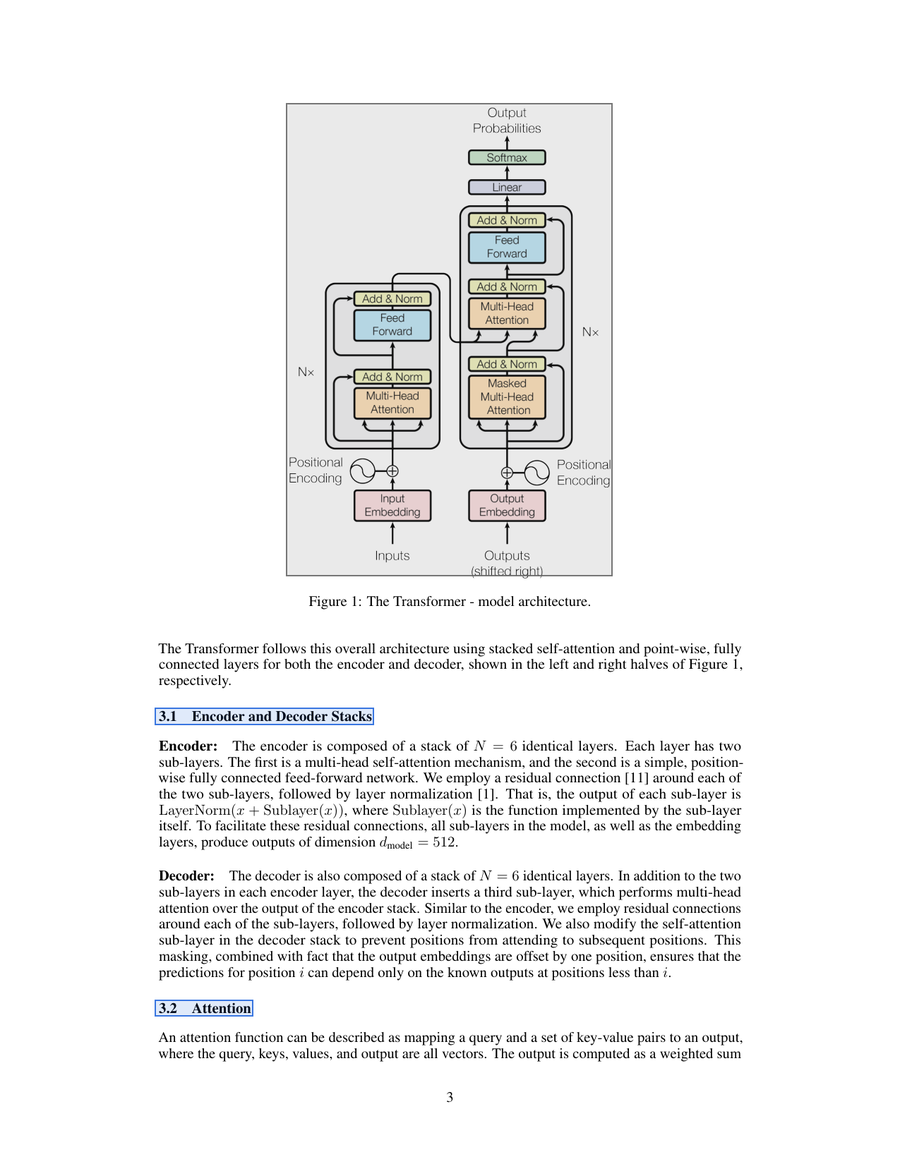

In [10]:
import fitz
from PIL import Image, ImageDraw
from IPython.display import display as ipy_display

COLORS = {
    'document_title':(220,50,50),'paragraph_title':(30,100,220),
    'abstract':(20,160,160),'paragraph':(40,160,40),'text':(40,160,40),
    'table':(230,120,0),'formula':(150,50,220),'figure_caption':(0,180,200),
    'algorithm':(220,0,180),'image':(100,100,100),
}

def vis_page(result, page_num=0, dpi=150):
    src = Path(result.source_file)
    doc = fitz.open(str(src))
    pg = doc.load_page(page_num)
    pix = pg.get_pixmap(matrix=fitz.Matrix(dpi/72, dpi/72))
    img = Image.frombytes('RGB',[pix.width,pix.height],pix.samples)
    doc.close()
    draw = ImageDraw.Draw(img,'RGBA')
    w,h = img.size
    for el in result.pages[page_num].elements:
        if not el.bbox or len(el.bbox)!=4: continue
        c = COLORS.get(el.label,(180,180,0))
        x1,y1,x2,y2=[int(el.bbox[i]*(w if i%2==0 else h)/1000) for i in range(4)]
        if x2>x1 and y2>y1:
            draw.rectangle([x1,y1,x2,y2],fill=(*c,35),outline=(*c,220),width=2)
            draw.text((x1+3,max(y1-16,0)),el.label.replace('_',' '),fill=(255,255,255))
    ipy_display(img.resize((900,int(h*900/w)),Image.LANCZOS))

if 'result' in dir():
    PAGE = 1   # change page index here
    vis_page(result, page_num=PAGE)
else:
    print('⚠ Run Cell 3 first.')

## 🧩 Cell 6 — Chunking

In [11]:
from collections import Counter
from doc_parser.chunker import structure_aware_chunking

if 'result' not in dir():
    print('⚠ Run Cell 3 first.')
else:
    all_chunks = []
    for page in result.pages:
        all_chunks.extend(structure_aware_chunking(
            page.elements,
            source_file=Path(result.source_file).name,
            page=page.page_num,
        ))
    counts = Counter(c.modality for c in all_chunks)
    print(f'✅ {len(all_chunks)} chunks — {dict(counts)}')
    for chunk in all_chunks[:3]:
        print(f'\n  [{chunk.chunk_id}] {chunk.modality} | atomic={chunk.is_atomic}')
        print(f'  types: {chunk.element_types}')
        print(f'  text : {chunk.text[:120]}...')

✅ 5 chunks — {'text': 4, 'image': 1}

  [sample.pdf_1_0] text | atomic=False
  types: ['doc_title']
  text : #...

  [sample.pdf_1_1] text | atomic=False
  types: ['paragraph_title']
  text : ##...

  [sample.pdf_2_0] image | atomic=True
  types: ['image']
  text : ...


## 🖼️ Cell 7 — Image Captioning via Groq

- Images → `qwen/qwen3.6-27b` (vision)
- Tables / Formulas / Algorithms → `meta/llama-3.3-70b-versatile`

Set `CAPTION=False` for fully offline mode.

In [17]:
import asyncio
from doc_parser.ingestion.image_captioner import enrich_chunks

# Set True if you have a valid GROQ_API_KEY in .env, otherwise set False
CAPTION = False   # Set False to skip API call (fully offline mode)

if "all_chunks" not in dir():
    print("⚠ Run Cell 6 first.")
elif not CAPTION:
    print("✅ Captioning skipped (CAPTION=False) — image chunks will use raw OCR text.")
elif not settings.groq_api_key:
    print("✗ GROQ_API_KEY not set — skipping.")
    print("  Get a free key at https://console.groq.com")
else:
    try:
        non_text = [c for c in all_chunks if c.modality != "text"]
        print(f"Captioning {len(non_text)} non-text chunks via Groq...")
        all_chunks = await enrich_chunks(
            all_chunks,
            pdf_path=Path(result.source_file),
            settings=settings,
            max_concurrent=2,
        )
        captioned = [c for c in all_chunks if c.caption]
        print(f"✅ {len(captioned)} chunks captioned")
        if captioned:
            print(f"  Sample: {captioned[0].caption[:150]}")
    except Exception as e:
        print(f"⚠ Groq API Key invalid ({e}) — proceeding without captioning.")


✅ Captioning skipped (CAPTION=False) — image chunks will use raw OCR text.


## 🔢 Cell 8 — Embed (sentence-transformers, local CPU)

First run downloads `all-MiniLM-L6-v2` (~22 MB) from HuggingFace automatically.

In [18]:
from doc_parser.ingestion.embedder import get_embedder, embed_chunks

if 'all_chunks' not in dir():
    print('⚠ Run Cell 6 first.')
else:
    embedder = get_embedder(settings)
    print(f'Embedding {len(all_chunks)} chunks with [{settings.embedding_model}]...')
    dense, sparse = await embed_chunks(all_chunks, embedder, settings)
    print(f'✅ Dense : {len(dense)} vectors × {len(dense[0])}d')
    print(f'   Sparse: {len(sparse)} BM25 vectors')

2026-08-01 22:12:43,864 [INFO] doc_parser.ingestion.embedder: Initialising embedding provider: local
2026-08-01 22:12:47,815 [INFO] doc_parser.ingestion.embedder: Loading sentence-transformers model 'all-MiniLM-L6-v2' (first run downloads weights)
2026-08-01 22:12:47,821 [INFO] sentence_transformers.base.model: No device provided, using cpu
2026-08-01 22:12:48,868 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-08-01 22:12:49,070 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
2026-08-01 22:12:49,419 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-08-01 22:12:49,490 [INFO] httpx: HTTP Request: HEAD https

Embedding 5 chunks with [all-MiniLM-L6-v2]...
✅ Dense : 5 vectors × 384d
   Sparse: 5 BM25 vectors


## 🗄️ Cell 9 — Upsert to Qdrant

In [19]:
from doc_parser.ingestion.vector_store import QdrantDocumentStore

if 'dense' not in dir():
    print('⚠ Run Cell 8 first.')
else:
    store = QdrantDocumentStore(settings)
    await store.create_collection(overwrite=False)
    upserted = await store.upsert_chunks(all_chunks, dense, sparse)
    print(f'✅ Upserted {upserted} points → "{settings.qdrant_collection_name}"')
    print(f'   Dashboard: {settings.qdrant_url}/dashboard')

/home/user/snap/Downloads/AI_SECURITY_LEARNING/multi-modal-rag-master/notebooks/../src/doc_parser/ingestion/vector_store.py:51: UserWarning: Api key is used with an insecure connection.
  self._client = AsyncQdrantClient(url=settings.qdrant_url, api_key=api_key)
2026-08-01 22:13:07,343 [INFO] httpx: HTTP Request: GET http://localhost:6333 "HTTP/1.1 200 OK"
2026-08-01 22:13:07,347 [INFO] httpx: HTTP Request: GET http://localhost:6333/collections "HTTP/1.1 200 OK"
2026-08-01 22:13:07,350 [INFO] doc_parser.ingestion.vector_store: Creating collection 'documents'
2026-08-01 22:13:07,692 [INFO] httpx: HTTP Request: PUT http://localhost:6333/collections/documents "HTTP/1.1 200 OK"
2026-08-01 22:13:07,765 [INFO] httpx: HTTP Request: PUT http://localhost:6333/collections/documents/points?wait=true "HTTP/1.1 200 OK"
2026-08-01 22:13:07,770 [INFO] doc_parser.ingestion.vector_store: Upserted 5 points to collection 'documents'


✅ Upserted 5 points → "documents"
   Dashboard: http://localhost:6333/dashboard


## 🔍 Cell 10 — Hybrid Search + BGE Re-ranking

In [9]:
from doc_parser.retrieval.reranker import get_reranker
from doc_parser.ingestion.vector_store import QdrantDocumentStore
from doc_parser.ingestion.embedder import get_embedder

# ── Your query ────────────────────────────────────────────────────────────────
QUERY           = 'What is Scaled Dot-Product Attention?'
TOP_K           = 20     # candidates from Qdrant
TOP_N           = 5      # final results after reranking
FILTER_MODALITY = None   # None | 'text' | 'image' | 'table' | 'formula'
# ─────────────────────────────────────────────────────────────────────────────

if 'store' not in dir():
    store = QdrantDocumentStore(settings)

embedder = get_embedder(settings)
candidates = await store.search(
    query_text=QUERY, embedder=embedder, settings=settings,
    top_k=TOP_K, filter_modality=FILTER_MODALITY,
)
print(f'Retrieved {len(candidates)} candidates from Qdrant Cloud')

reranker = get_reranker(settings)   # BGE local
results  = await reranker.rerank(QUERY, candidates, top_n=TOP_N)
print(f'Re-ranked with [{settings.reranker_backend}] → top {len(results)}')
print()
for i, r in enumerate(results, 1):
    score = r.get('rerank_score', 0)
    print(f'[{i}] score={score:.3f}  modality={r.get("modality")}  page={r.get("page")}')
    print(f'    {r.get("text","")[:200]}')
    if r.get('caption'):
        print(f'    caption: {r["caption"][:120]}')
    print()

2026-08-03 11:59:57,942 [INFO] doc_parser.ingestion.embedder: Initialising embedding provider: local
2026-08-03 11:59:57,943 [INFO] doc_parser.ingestion.embedder: Loading sentence-transformers model 'all-MiniLM-L6-v2' (first run downloads weights)
2026-08-03 11:59:57,948 [INFO] sentence_transformers.base.model: No device provided, using cpu
2026-08-03 11:59:58,801 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
2026-08-03 11:59:59,129 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json "HTTP/1.1 200 OK"
2026-08-03 11:59:59,476 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
2026-08-03 11:59:59,558 [INFO] httpx: HTTP Request: HEAD https

Retrieved 20 candidates from Qdrant Cloud


2026-08-03 12:00:10,824 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/BAAI/bge-reranker-base/resolve/main/modules.json "HTTP/1.1 404 Not Found"
2026-08-03 12:00:10,834 [INFO] sentence_transformers.base.model: No modules.json found for BAAI/bge-reranker-base, initializing a new CrossEncoder model.
2026-08-03 12:00:11,418 [INFO] httpx: HTTP Request: GET https://huggingface.co/api/models/BAAI/bge-reranker-base "HTTP/1.1 200 OK"
2026-08-03 12:00:11,764 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/BAAI/bge-reranker-base/resolve/main/config.json "HTTP/1.1 307 Temporary Redirect"
2026-08-03 12:00:12,173 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/BAAI/bge-reranker-base/2cfc18c9415c912f9d8155881c133215df768a70/config.json "HTTP/1.1 200 OK"
2026-08-03 12:00:12,793 [INFO] httpx: HTTP Request: HEAD https://huggingface.co/BAAI/bge-reranker-base/resolve/main/adapter_config.json "HTTP/1.1 404 Not Found"
2026-08-03 12:00:13,566 [INFO] httpx: H

Re-ranked with [bge] → top 5

[1] score=0.703  modality=image  page=4
    TYPE: DIAGRAM
CAPTION: A technical diagram illustrating the architecture of Scaled Dot-Product Attention and Multi-Head Attention mechanisms used in transformer models.
DETAIL:
- Left Diagram (Scaled 
    caption: A technical diagram illustrating the architecture of Scaled Dot-Product Attention and Multi-Head Attention mechanisms us

[2] score=0.000  modality=formula  page=6
    $$

$$
    caption: $$

$$

[3] score=0.000  modality=formula  page=5
    $$

$$
    caption: $$

$$

[4] score=0.000  modality=formula  page=7
    $$

$$
    caption: $$

$$

[5] score=0.000  modality=formula  page=6
    $$

$$
    caption: $$

$$



## 🤖 Cell 11 — Full RAG Answer Generation

Passes the top reranked context chunks to **Groq (`llama-3.3-70b-versatile`)** to generate a final grounded answer with page citations.

In [10]:
from doc_parser.api.dependencies import get_llm_client

# ── Build context from reranked results (modality-aware) ─────────────────────
context_parts = []
for r in results:
    page = r.get('page', '?')
    modality = r.get('modality', 'text')
    text_val = (r.get('text') or '').strip()
    caption_val = (r.get('caption') or '').strip()
    
    if modality == 'table':
        content = f"{text_val}\nTable Content:\n{caption_val}".strip()
    elif modality in ('image', 'formula'):
        content = f"Description: {caption_val}\n{text_val}".strip()
    else:
        content = text_val or caption_val
        
    context_parts.append(f"[Page {page} | Modality: {modality}]\n{content}")

context = "\n\n---\n\n".join(context_parts)

# ── Generate answer via Groq / OpenAI ────────────────────────────────────────
llm = get_llm_client()
model = settings.groq_text_model if settings.groq_api_key else settings.openai_llm_model

system_prompt = (
    "You are a precise document assistant. Answer the question using ONLY the provided context. "
    "If the answer is not in the context, say 'I don't have enough information to answer this.' "
    "Cite the source page numbers when possible."
)

response = await llm.chat.completions.create(
    model=model,
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": f"Context:\n{context}\n\nQuestion: {QUERY}"}
    ],
    temperature=0.0,
)

answer = response.choices[0].message.content
print(f"🤖 RAG Answer ({model}):\n")
print(answer)

2026-08-03 12:00:56,894 [INFO] httpx: HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


🤖 RAG Answer (llama-3.3-70b-versatile):

According to the context provided on Page 4, Scaled Dot-Product Attention is a mechanism used in transformer models, which takes inputs Q, K, and V, and performs the following operations: MatMul, Scale, Mask (optional), SoftMax, and a final MatMul. The structure of the Scaled Dot-Product Attention module is as follows: 
- Inputs: Q, K, V
- Operations: MatMul, Scale, Mask (opt.), SoftMax, MatMul.
